# Exploratory Analysis of TANGEDCO Electricity Demand

### Tamil Nadu Electricity Demand, Peak Load, Unmet Demand and Weather Analysis

**Study Period:** 01 January 2021 to 28 April 2024

This single Jupyter Notebook combines the complete data-analysis workflow for the project. The structure follows the useful organization data ingestion and inspection, data cleaning, datatype handling, feature engineering, relational merging, exploratory analysis, and standalone visualizations.


## 1. Data Sources and Dataset Description

Four datasets are used in this notebook:

| Dataset | Main content | Use in project |
|---|---|---|
| `corrected_peak_met_MW(1).csv` | Daily peak power supplied by state | Tamil Nadu peak load |
| `peak_unmet_MW(2).csv` | Daily peak unmet demand by state | Tamil Nadu unmet demand |
| `corrected_daily_energy_met_MU(1).csv` | Daily energy supplied by state | Tamil Nadu energy supplied |
| `Tamil_Nadu_21_24(3).csv` | Daily Tamil Nadu weather variables | Weather-demand relationship |

The electricity datasets contain state-wise columns, so the Tamil Nadu column is selected **after the individual datasets have been cleaned**. The weather dataset is already specific to Tamil Nadu.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.max_rows", 100)


## 1.1. File Paths and Study Period

The raw CSV files are expected to be in the same folder as this notebook. The date range is fixed to the actual project study period available in the selected data: **01-01-2021 to 28-04-2024**.


In [2]:
weather_file = "../dataset/raw Data/Tamil_Nadu_21_24.csv"
peak_file = "../dataset/raw Data/peak_met_MW.csv"
unmet_file = "../dataset/raw Data/peak_unmet_MW.csv"
energy_file = "../dataset/raw Data/corrected_daily_energy_met_MU.csv"

start_date = "2021-01-01"
end_date = "2024-04-28"


# 1.2. Data Ingestion and Initial Inspection

Each dataset is loaded separately so that its cleaning process can be completed independently. No merging is performed at this stage.


In [3]:
df_weather = pd.read_csv(weather_file)
df_peak = pd.read_csv(peak_file)
df_unmet = pd.read_csv(unmet_file)
df_energy = pd.read_csv(energy_file)

print("Weather shape:", df_weather.shape)
print("Peak-load shape:", df_peak.shape)
print("Unmet-demand shape:", df_unmet.shape)
print("Energy-supplied shape:", df_energy.shape)


Weather shape: (16554, 22)
Peak-load shape: (3955, 40)
Unmet-demand shape: (3955, 40)
Energy-supplied shape: (3955, 40)


In [4]:
print("WEATHER DATA")
display(df_weather.head())
print("\nPEAK LOAD DATA")
display(df_peak.head())
print("\nUNMET DEMAND DATA")
display(df_unmet.head())
print("\nENERGY SUPPLIED DATA")
display(df_energy.head())


WEATHER DATA


,date,10m_u_component_of_wind_min,10m_u_component_of_wind_mean,10m_u_component_of_wind_max,10m_v_component_of_wind_min,10m_v_component_of_wind_mean,10m_v_component_of_wind_max,2m_temperature_min,2m_temperature_mean,2m_temperature_max,2m_dewpoint_temperature_min,2m_dewpoint_temperature_mean,2m_dewpoint_temperature_max,surface_solar_radiation_downwards_min,surface_solar_radiation_downwards_mean,surface_solar_radiation_downwards_max,total_cloud_cover_min,total_cloud_cover_mean,total_cloud_cover_max,utci_min,utci_mean,utci_max
0,1979-01-01,-2.559480,-1.585596,-0.524333,-2.313436,-1.580627,-0.939023,292.60538,296.58994,299.82892,291.17227,292.46484,293.60464,0.0,731095.94,2527539.2,0.057654,0.338048,0.662992,290.03452,295.700419,302.95456
1,1979-01-02,-3.077931,-1.704346,-0.587982,-2.630232,-1.879424,-1.233038,293.12823,296.78720,300.11032,291.14066,292.33817,293.21967,0.0,679148.20,2375735.5,0.138998,0.368613,0.667559,290.03452,295.700419,302.95456
2,1979-01-03,-3.206645,-1.621501,0.011909,-2.794011,-1.810261,-1.062530,292.08072,296.41495,299.79562,290.24557,291.50375,292.93750,0.0,787916.44,2662401.8,0.026348,0.191770,0.494071,288.72998,295.409465,303.59866
3,1979-01-04,-2.986116,-1.310420,0.388729,-2.644209,-1.763320,-0.886788,291.31000,296.02420,299.83698,289.66156,290.75710,291.95587,0.0,868250.25,2973727.8,0.012963,0.112058,0.292393,287.69952,295.039632,303.69180
4,1979-01-05,-2.748085,-1.176547,0.548578,-1.956719,-1.481688,-0.882275,291.40884,296.08980,299.91742,289.08566,290.46793,292.58267,0.0,857098.56,3005456.0,0.062340,0.355414,0.763826,287.11470,295.386882,304.15250



PEAK LOAD DATA


,Date,Andaman and Nicobar Islands,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,Dadra and Nagar Haveli,Daman and Diu,Delhi,Goa,Gujarat,Haryana,Himachal Pradesh,Jammu and Kashmir,Jharkhand,Karnataka,Kerala,Lakshadweep,Madhya Pradesh,Maharashtra,Manipur,Meghalaya,Mizoram,Nagaland,Odisha,Puducherry,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal,AMNSIL,Damodar Valley Corporation,Total
0,2013-01-01,NaN,11056.0,104.0,955.0,2087.0,228.0,2866.0,592.0,201.0,3811.0,415.0,11064.0,5219.0,1352.0,1837.0,1064.0,8485.0,3220.0,NaN,8592.0,17522.0,126.0,277.0,75.0,88.0,3276.0,281.0,4741.0,8870.0,96.0,11924.0,NaN,182.0,9872.0,1652.0,6068.0,348.0,2585.0,131131.0
1,2013-01-02,NaN,10987.0,113.0,980.0,1849.0,215.0,2926.0,598.0,228.0,3783.0,389.0,11170.0,5654.0,1359.0,1917.0,1023.0,8589.0,3197.0,NaN,8912.0,17477.0,119.0,293.0,75.0,88.0,3353.0,298.0,4947.0,9597.0,111.0,11816.0,NaN,166.0,9819.0,1781.0,6180.0,319.0,2665.0,132993.0
2,2013-01-03,NaN,11071.0,111.0,1060.0,2075.0,231.0,2891.0,638.0,242.0,3926.0,408.0,11418.0,5871.0,1372.0,2146.0,995.0,8806.0,3212.0,NaN,8880.0,17173.0,114.0,275.0,68.0,92.0,3396.0,303.0,5142.0,9742.0,113.0,11887.0,NaN,185.0,10079.0,1759.0,5880.0,362.0,2626.0,134549.0
3,2013-01-04,NaN,11194.0,113.0,985.0,1928.0,212.0,2905.0,646.0,241.0,3626.0,403.0,10761.0,5720.0,1360.0,1828.0,1063.0,8580.0,3187.0,NaN,9185.0,18513.0,111.0,294.0,68.0,87.0,3448.0,296.0,5313.0,9204.0,65.0,12111.0,NaN,181.0,10211.0,1710.0,6520.0,368.0,2578.0,135015.0
4,2013-01-05,NaN,10940.0,110.0,986.0,2030.0,212.0,2875.0,634.0,241.0,3588.0,364.0,11021.0,5433.0,1308.0,2011.0,1027.0,8249.0,3001.0,NaN,8039.0,17039.0,116.0,288.0,69.0,86.0,3478.0,265.0,4935.0,8942.0,67.0,11311.0,NaN,195.0,9919.0,1694.0,5474.0,372.0,2609.0,128928.0



UNMET DEMAND DATA


,Date,Andaman and Nicobar Islands,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,Dadra and Nagar Haveli,Daman and Diu,Delhi,Goa,Gujarat,Haryana,Himachal Pradesh,Jammu and Kashmir,Jharkhand,Karnataka,Kerala,Lakshadweep,Madhya Pradesh,Maharashtra,Manipur,Meghalaya,Mizoram,Nagaland,Odisha,Puducherry,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal,AMNSIL,Damodar Valley Corporation,Total
0,2013-01-01,NaN,0.0,11.0,194.0,300.0,0.0,5.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,100.0,0.0,400.0,150.0,NaN,0.0,130.0,4.0,3.0,5.0,12.0,0.0,0.0,0.0,0.0,0.0,683.0,NaN,10.0,1055.0,40.0,0.0,0.0,0.0,3123.0
1,2013-01-02,NaN,300.0,2.0,188.0,600.0,0.0,5.0,0.0,0.0,7.0,0.0,0.0,172.0,0.0,100.0,0.0,500.0,150.0,NaN,0.0,172.0,11.0,2.0,5.0,12.0,0.0,0.0,0.0,0.0,0.0,702.0,NaN,25.0,1730.0,40.0,0.0,0.0,0.0,4723.0
2,2013-01-03,NaN,0.0,4.0,108.0,400.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,500.0,150.0,NaN,0.0,548.0,11.0,5.0,12.0,8.0,0.0,0.0,0.0,0.0,0.0,687.0,NaN,7.0,1555.0,40.0,2.0,0.0,0.0,4142.0
3,2013-01-04,NaN,0.0,2.0,163.0,300.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,350.0,150.0,NaN,0.0,382.0,14.0,1.0,12.0,13.0,0.0,0.0,0.0,0.0,0.0,698.0,NaN,11.0,1845.0,40.0,0.0,0.0,0.0,4086.0
4,2013-01-05,NaN,0.0,5.0,122.0,100.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,76.0,300.0,75.0,NaN,0.0,432.0,9.0,7.0,11.0,14.0,0.0,0.0,0.0,0.0,0.0,678.0,NaN,10.0,1555.0,40.0,0.0,0.0,0.0,3539.0



ENERGY SUPPLIED DATA


,Date,Andaman and Nicobar Islands,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,Dadra and Nagar Haveli,Daman and Diu,Delhi,Goa,Gujarat,Haryana,Himachal Pradesh,Jammu and Kashmir,Jharkhand,Karnataka,Kerala,Lakshadweep,Madhya Pradesh,Maharashtra,Manipur,Meghalaya,Mizoram,Nagaland,Odisha,Puducherry,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal,AMNSIL,Damodar Valley Corporation,Total
0,2013-01-01,NaN,247.4,1.5,18.6,36.6,3.8,64.4,13.5,5.0,64.9,8.1,231.1,98.3,24.7,28.6,21.6,171.7,57.1,NaN,162.0,353.1,1.5,5.4,1.2,1.5,67.5,5.5,91.5,175.6,1.7,245.3,NaN,2.9,219.2,31.7,102.0,6.0,59.3,2629.8
1,2013-01-02,NaN,253.0,1.7,17.5,40.5,3.8,64.2,13.8,5.3,65.0,8.4,237.5,104.6,25.0,38.4,21.4,174.6,57.7,NaN,173.4,361.7,1.7,4.9,1.2,1.6,64.4,5.7,92.4,189.0,1.7,247.7,NaN,2.9,214.9,33.0,101.4,6.0,57.9,2693.9
2,2013-01-03,NaN,256.1,1.7,17.8,39.3,3.9,63.7,14.9,5.7,67.2,7.9,241.8,113.2,25.7,43.3,21.4,179.9,58.4,NaN,176.4,357.7,1.8,4.9,1.2,1.6,63.7,5.9,94.7,196.0,1.7,253.8,NaN,3.3,227.2,33.6,101.5,7.4,58.7,2753.0
3,2013-01-04,NaN,252.6,1.7,18.7,40.3,3.7,63.4,15.2,5.8,63.5,8.0,242.2,110.7,26.0,37.4,21.0,177.2,58.8,NaN,176.0,365.0,1.5,5.3,1.2,1.6,66.3,5.8,96.8,189.0,1.3,252.2,NaN,2.5,229.2,34.1,118.5,7.7,60.0,2760.2
4,2013-01-05,NaN,248.6,1.6,17.6,41.5,3.7,62.7,15.0,5.7,61.8,7.3,234.5,103.7,24.1,40.6,21.2,167.0,53.9,NaN,162.5,356.7,1.5,5.1,1.2,1.7,64.2,5.3,89.1,183.1,1.4,243.9,NaN,2.4,219.6,32.8,102.8,7.5,59.5,2650.8


In [5]:
print("Column names")
print("\nWeather:", df_weather.columns.tolist())
print("\nPeak:", df_peak.columns.tolist())
print("\nUnmet:", df_unmet.columns.tolist())
print("\nEnergy:", df_energy.columns.tolist())


Column names

Weather: ['date', '10m_u_component_of_wind_min', '10m_u_component_of_wind_mean', '10m_u_component_of_wind_max', '10m_v_component_of_wind_min', '10m_v_component_of_wind_mean', '10m_v_component_of_wind_max', '2m_temperature_min', '2m_temperature_mean', '2m_temperature_max', '2m_dewpoint_temperature_min', '2m_dewpoint_temperature_mean', '2m_dewpoint_temperature_max', 'surface_solar_radiation_downwards_min', 'surface_solar_radiation_downwards_mean', 'surface_solar_radiation_downwards_max', 'total_cloud_cover_min', 'total_cloud_cover_mean', 'total_cloud_cover_max', 'utci_min', 'utci_mean', 'utci_max']

Peak: ['Date', 'Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagala

# 2. Data Cleaning

The cleaning steps are:

- Standardize the date column name.
- Convert the date field to Pandas datetime.
- Restrict the data to the project study period.
- Remove duplicate dates.
- Convert analytical columns to numeric values where required.
- Check missing values after cleaning.
- Save the cleaned dataset immediately.


## 2.1 Clean Peak Load Dataset

The corrected peak-load dataset is cleaned first. The complete state-wise cleaned dataset is saved before Tamil Nadu is selected.


In [6]:
df_peak = df_peak.copy()
df_peak.rename(columns={"date": "Date", "DATE": "Date"}, inplace=True)
df_peak["Date"] = pd.to_datetime(df_peak["Date"], errors="coerce")

df_peak = df_peak[(df_peak["Date"] >= start_date) & (df_peak["Date"] <= end_date)].copy()
df_peak = df_peak.dropna(subset=["Date"]).drop_duplicates(subset=["Date"], keep="first")

for col in df_peak.columns:
    if col != "Date":
        df_peak[col] = pd.to_numeric(df_peak[col], errors="coerce")

df_peak = df_peak.sort_values("Date").reset_index(drop=True)

print("Cleaned peak-load shape:", df_peak.shape)
print("Duplicate dates:", df_peak["Date"].duplicated().sum())
print("Missing values:", df_peak.isna().sum().sum())
display(df_peak.head())


Cleaned peak-load shape: (1196, 40)
Duplicate dates: 0
Missing values: 3782


,Date,Andaman and Nicobar Islands,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,Dadra and Nagar Haveli,Daman and Diu,Delhi,Goa,Gujarat,Haryana,Himachal Pradesh,Jammu and Kashmir,Jharkhand,Karnataka,Kerala,Lakshadweep,Madhya Pradesh,Maharashtra,Manipur,Meghalaya,Mizoram,Nagaland,Odisha,Puducherry,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal,AMNSIL,Damodar Valley Corporation,Total
0,2021-01-01,NaN,8804.0,131.0,1325.0,4582.0,285.0,4067.0,757.0,269.0,4918.0,490.0,16505.0,6270.0,1859.0,2754.0,1625.0,11706.0,3459.0,NaN,15425.0,22156.0,215.0,333.0,104.0,130.0,3769.0,332.0,6516.0,14088.0,105.0,11864.0,11302.0,217.0,17642.0,2232.0,5622.0,838.0,3033.0,185729.0
1,2021-01-02,NaN,8648.0,137.0,1390.0,4836.0,264.0,4032.0,809.0,316.0,4233.0,504.0,16936.0,6403.0,1866.0,2916.0,1546.0,11556.0,3480.0,NaN,15076.0,22881.0,233.0,377.0,110.0,136.0,3870.0,340.0,5898.0,13720.0,119.0,12401.0,11044.0,216.0,17169.0,2225.0,5671.0,756.0,3050.0,185164.0
2,2021-01-03,NaN,8505.0,137.0,1362.0,4809.0,232.0,4044.0,797.0,295.0,4046.0,494.0,16371.0,5480.0,1729.0,2359.0,1496.0,11008.0,3209.0,NaN,14790.0,22479.0,233.0,377.0,110.0,136.0,3860.0,298.0,5809.0,13368.0,123.0,11101.0,10745.0,219.0,14631.0,1970.0,5626.0,802.0,3027.0,176077.0
3,2021-01-04,NaN,8774.0,133.0,1418.0,4806.0,255.0,4105.0,829.0,325.0,4413.0,517.0,16935.0,5825.0,1823.0,2645.0,1445.0,11626.0,3528.0,NaN,14989.0,23028.0,230.0,380.0,114.0,130.0,3865.0,355.0,6032.0,12843.0,144.0,12821.0,11249.0,218.0,15567.0,2149.0,6298.0,793.0,2983.0,183590.0
4,2021-01-05,NaN,8646.0,127.0,1428.0,4566.0,239.0,4131.0,825.0,335.0,4186.0,504.0,16869.0,5474.0,1844.0,2352.0,1517.0,11322.0,3615.0,NaN,14311.0,22103.0,228.0,365.0,105.0,141.0,4038.0,349.0,5872.0,11188.0,143.0,12736.0,11497.0,220.0,15278.0,2187.0,6400.0,799.0,3083.0,179023.0


In [7]:
df_peak.to_csv("clean_peak_met_MW.csv", index=False)
print("Saved cleaned dataset: clean_peak_met_MW.csv")


Saved cleaned dataset: clean_peak_met_MW.csv


## 2.2 Clean Peak Unmet Demand Dataset

The unmet-demand dataset is cleaned independently and saved immediately as `clean_peak_unmet_MW.csv`.


In [8]:
df_unmet = df_unmet.copy()
df_unmet.rename(columns={"date": "Date", "DATE": "Date"}, inplace=True)
df_unmet["Date"] = pd.to_datetime(df_unmet["Date"], errors="coerce")

df_unmet = df_unmet[(df_unmet["Date"] >= start_date) & (df_unmet["Date"] <= end_date)].copy()
df_unmet = df_unmet.dropna(subset=["Date"]).drop_duplicates(subset=["Date"], keep="first")

for col in df_unmet.columns:
    if col != "Date":
        df_unmet[col] = pd.to_numeric(df_unmet[col], errors="coerce")

df_unmet = df_unmet.sort_values("Date").reset_index(drop=True)

print("Cleaned unmet-demand shape:", df_unmet.shape)
print("Duplicate dates:", df_unmet["Date"].duplicated().sum())
print("Missing values:", df_unmet.isna().sum().sum())
display(df_unmet.head())


Cleaned unmet-demand shape: (1196, 40)
Duplicate dates: 0
Missing values: 3782


,Date,Andaman and Nicobar Islands,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,Dadra and Nagar Haveli,Daman and Diu,Delhi,Goa,Gujarat,Haryana,Himachal Pradesh,Jammu and Kashmir,Jharkhand,Karnataka,Kerala,Lakshadweep,Madhya Pradesh,Maharashtra,Manipur,Meghalaya,Mizoram,Nagaland,Odisha,Puducherry,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal,AMNSIL,Damodar Valley Corporation,Total
0,2021-01-01,NaN,0.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,550.0,102.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,677.0
1,2021-01-02,NaN,0.0,2.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,550.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,570.0
2,2021-01-03,NaN,0.0,2.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,450.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,470.0
3,2021-01-04,NaN,0.0,2.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,76.0,600.0,0.0,0.0,0.0,NaN,0.0,0.0,2.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,777.0
4,2021-01-05,NaN,0.0,2.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,600.0,0.0,0.0,0.0,NaN,0.0,0.0,3.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,628.0


In [9]:
df_unmet.to_csv("clean_peak_unmet_MW.csv", index=False)
print("Saved cleaned dataset: clean_peak_unmet_MW.csv")


Saved cleaned dataset: clean_peak_unmet_MW.csv


## 2.3 Clean Daily Energy Supplied Dataset

The daily energy-supplied dataset is cleaned independently and saved immediately as `clean_daily_energy_met_MU.csv`.


In [10]:
df_energy = df_energy.copy()
df_energy.rename(columns={"date": "Date", "DATE": "Date"}, inplace=True)
df_energy["Date"] = pd.to_datetime(df_energy["Date"], errors="coerce")

df_energy = df_energy[(df_energy["Date"] >= start_date) & (df_energy["Date"] <= end_date)].copy()
df_energy = df_energy.dropna(subset=["Date"]).drop_duplicates(subset=["Date"], keep="first")

for col in df_energy.columns:
    if col != "Date":
        df_energy[col] = pd.to_numeric(df_energy[col], errors="coerce")

df_energy = df_energy.sort_values("Date").reset_index(drop=True)

print("Cleaned energy-supplied shape:", df_energy.shape)
print("Duplicate dates:", df_energy["Date"].duplicated().sum())
print("Missing values:", df_energy.isna().sum().sum())
display(df_energy.head())


Cleaned energy-supplied shape: (1196, 40)
Duplicate dates: 0
Missing values: 3782


,Date,Andaman and Nicobar Islands,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,Dadra and Nagar Haveli,Daman and Diu,Delhi,Goa,Gujarat,Haryana,Himachal Pradesh,Jammu and Kashmir,Jharkhand,Karnataka,Kerala,Lakshadweep,Madhya Pradesh,Maharashtra,Manipur,Meghalaya,Mizoram,Nagaland,Odisha,Puducherry,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal,AMNSIL,Damodar Valley Corporation,Total
0,2021-01-01,NaN,156.4,2.2,24.0,87.7,4.5,85.3,17.3,6.1,77.0,10.3,334.5,127.8,33.2,57.6,26.9,207.0,68.7,NaN,295.4,442.4,3.0,6.7,1.6,2.3,68.4,6.5,124.3,264.4,1.8,246.3,204.8,3.6,313.6,40.2,113.8,17.8,65.5,3548.9
1,2021-01-02,NaN,163.0,2.2,23.0,82.7,4.5,85.1,18.2,6.7,70.5,10.4,339.7,123.9,33.8,54.3,26.3,208.5,68.8,NaN,293.1,454.0,3.0,6.8,1.7,2.2,70.4,6.7,116.3,258.3,2.0,251.7,206.4,3.6,304.6,41.5,113.2,15.2,63.5,3535.8
2,2021-01-03,NaN,157.6,2.2,22.9,85.1,3.8,86.6,18.6,6.7,67.9,10.5,330.9,110.0,31.1,48.8,25.8,198.9,64.5,NaN,286.9,448.4,3.3,6.6,1.7,2.3,70.7,6.2,108.6,245.4,2.0,233.6,202.1,3.8,264.2,36.7,103.9,17.5,64.6,3380.4
3,2021-01-04,NaN,163.6,2.3,23.7,84.4,4.0,86.6,19.0,7.1,73.2,10.4,339.5,112.3,32.6,44.2,25.6,208.1,70.9,NaN,281.4,452.6,3.2,7.0,1.7,2.2,70.6,6.9,112.6,227.2,2.3,251.7,207.1,3.5,276.8,39.8,109.6,17.8,63.5,3445.0
4,2021-01-05,NaN,166.1,2.3,24.4,82.0,4.0,87.0,18.8,7.4,70.5,10.8,341.8,104.0,33.5,40.2,25.7,208.8,72.4,NaN,274.7,444.8,3.0,6.7,1.6,2.3,74.8,7.1,109.5,215.3,2.3,259.4,211.7,2.8,278.3,40.8,118.6,18.1,65.2,3436.7


In [11]:
df_energy.to_csv("clean_daily_energy_met_MU.csv", index=False)
print("Saved cleaned dataset: clean_daily_energy_met_MU.csv")


Saved cleaned dataset: clean_daily_energy_met_MU.csv


## 2.4 Clean Tamil Nadu Weather Dataset

The weather dataset contains Tamil Nadu weather observations. The date column is standardized, the study period is applied, duplicate dates are removed and all measurement columns are converted to numeric values. The cleaned weather dataset is saved immediately.


In [12]:
df_weather = df_weather.copy()
df_weather.rename(columns={"date": "Date", "DATE": "Date"}, inplace=True)
df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")

df_weather = df_weather[(df_weather["Date"] >= start_date) & (df_weather["Date"] <= end_date)].copy()
df_weather = df_weather.dropna(subset=["Date"]).drop_duplicates(subset=["Date"], keep="first")

for col in df_weather.columns:
    if col != "Date":
        df_weather[col] = pd.to_numeric(df_weather[col], errors="coerce")

df_weather = df_weather.sort_values("Date").reset_index(drop=True)

print("Cleaned weather shape:", df_weather.shape)
print("Duplicate dates:", df_weather["Date"].duplicated().sum())
print("Missing values:", df_weather.isna().sum().sum())
display(df_weather.head())


Cleaned weather shape: (1213, 22)
Duplicate dates: 0
Missing values: 291


,Date,10m_u_component_of_wind_min,10m_u_component_of_wind_mean,10m_u_component_of_wind_max,10m_v_component_of_wind_min,10m_v_component_of_wind_mean,10m_v_component_of_wind_max,2m_temperature_min,2m_temperature_mean,2m_temperature_max,2m_dewpoint_temperature_min,2m_dewpoint_temperature_mean,2m_dewpoint_temperature_max,surface_solar_radiation_downwards_min,surface_solar_radiation_downwards_mean,surface_solar_radiation_downwards_max,total_cloud_cover_min,total_cloud_cover_mean,total_cloud_cover_max,utci_min,utci_mean,utci_max
0,2021-01-01,-3.390677,-1.778614,-0.119154,-3.329759,-2.311713,-1.514094,294.36832,296.95980,300.70380,292.05720,292.86734,293.69190,0.0,562883.44,2233692.5,0.654174,0.888196,0.976909,290.78820,297.768717,305.97366
1,2021-01-02,-2.889409,-1.360958,0.017706,-2.911205,-2.436029,-1.991597,294.72992,297.38937,299.74405,292.02783,293.95260,295.07355,0.0,390917.16,1416538.5,0.551596,0.745352,0.874311,290.09424,296.828552,305.44210
2,2021-01-03,-2.531320,-1.621806,-0.526552,-2.498247,-1.622157,-1.058285,295.89117,297.19925,299.76810,293.90933,295.08978,295.99730,0.0,407677.34,1564657.6,0.847460,0.904682,0.971867,289.73758,297.199320,304.95730
3,2021-01-04,-3.288685,-1.665369,-0.451963,-2.277523,-1.623663,-1.264241,295.83710,297.49515,300.25525,294.43488,294.91995,295.29196,0.0,357384.72,1325474.8,0.844107,0.897056,0.962279,290.69138,296.881429,304.32830
4,2021-01-05,-2.406144,-1.387112,-0.672298,-2.579983,-1.648392,-1.102462,296.14680,297.73360,300.41147,294.63144,295.39767,295.99330,0.0,436947.10,1579927.2,0.865547,0.940871,0.983825,289.17160,296.412842,305.12695


In [13]:
df_weather.to_csv("clean_tamil_nadu_21_24.csv", index=False)
print("Saved cleaned dataset: clean_tamil_nadu_21_24.csv")


Saved cleaned dataset: clean_tamil_nadu_21_24.csv


## 2.5 Cleaning Summary

At this point, four independent cleaned datasets have already been written to CSV files. This makes the preprocessing reproducible and keeps each source dataset available for later verification.


In [14]:
cleaning_summary = pd.DataFrame({
    "Dataset": [
        "Peak Load",
        "Peak Unmet Demand",
        "Daily Energy Supplied",
        "Tamil Nadu Weather"
    ],
    "Rows": [len(df_peak), len(df_unmet), len(df_energy), len(df_weather)],
    "Columns": [df_peak.shape[1], df_unmet.shape[1], df_energy.shape[1], df_weather.shape[1]],
    "Duplicate_Dates": [
        df_peak["Date"].duplicated().sum(),
        df_unmet["Date"].duplicated().sum(),
        df_energy["Date"].duplicated().sum(),
        df_weather["Date"].duplicated().sum()
    ],
    "Total_Missing_Values": [
        int(df_peak.isna().sum().sum()),
        int(df_unmet.isna().sum().sum()),
        int(df_energy.isna().sum().sum()),
        int(df_weather.isna().sum().sum())
    ]
})
display(cleaning_summary)


,Dataset,Rows,Columns,Duplicate_Dates,Total_Missing_Values
0,Peak Load,1196,40,0,3782
1,Peak Unmet Demand,1196,40,0,3782
2,Daily Energy Supplied,1196,40,0,3782
3,Tamil Nadu Weather,1213,22,0,291


# 3. Merge Tamil Nadu Electricity Data

After the four source datasets have been cleaned and saved,we select the **Tamil Nadu** column from the three state-wise electricity datasets.

The selected variables are renamed:

- `Peak_Load_MW`
- `Unmet_Demand_MW`
- `Energy_Supplied_MU`


In [15]:
df_tn_peak = df_peak[["Date", "Tamil Nadu"]].copy()
df_tn_peak.rename(columns={"Tamil Nadu": "Peak_Load_MW"}, inplace=True)

df_tn_unmet = df_unmet[["Date", "Tamil Nadu"]].copy()
df_tn_unmet.rename(columns={"Tamil Nadu": "Unmet_Demand_MW"}, inplace=True)

df_tn_energy = df_energy[["Date", "Tamil Nadu"]].copy()
df_tn_energy.rename(columns={"Tamil Nadu": "Energy_Supplied_MU"}, inplace=True)

print("Tamil Nadu peak-load data:")
display(df_tn_peak.head())
print("Tamil Nadu unmet-demand data:")
display(df_tn_unmet.head())
print("Tamil Nadu energy-supplied data:")
display(df_tn_energy.head())


Tamil Nadu peak-load data:


,Date,Peak_Load_MW
0,2021-01-01,11864.0
1,2021-01-02,12401.0
2,2021-01-03,11101.0
3,2021-01-04,12821.0
4,2021-01-05,12736.0


Tamil Nadu unmet-demand data:


,Date,Unmet_Demand_MW
0,2021-01-01,0.0
1,2021-01-02,0.0
2,2021-01-03,0.0
3,2021-01-04,0.0
4,2021-01-05,0.0


Tamil Nadu energy-supplied data:


,Date,Energy_Supplied_MU
0,2021-01-01,246.3
1,2021-01-02,251.7
2,2021-01-03,233.6
3,2021-01-04,251.7
4,2021-01-05,259.4


# 3.1 Relational Merge

The cleaned Tamil Nadu electricity datasets and the cleaned Tamil Nadu weather dataset are now merged using the common `Date` field. An **inner merge** is used so that the final analytical dataset contains dates available across all required sources.


In [16]:
merged_df = df_tn_peak.merge(df_tn_unmet, on="Date", how="inner")
merged_df = merged_df.merge(df_tn_energy, on="Date", how="inner")
merged_df = merged_df.merge(df_weather, on="Date", how="inner")

merged_df = merged_df.sort_values("Date").reset_index(drop=True)

print("Merged dataset shape:", merged_df.shape)
print("Date range:", merged_df["Date"].min(), "to", merged_df["Date"].max())
display(merged_df.head())


Merged dataset shape: (1195, 25)
Date range: 2021-01-01 00:00:00 to 2024-04-27 00:00:00


,Date,Peak_Load_MW,Unmet_Demand_MW,Energy_Supplied_MU,10m_u_component_of_wind_min,10m_u_component_of_wind_mean,10m_u_component_of_wind_max,10m_v_component_of_wind_min,10m_v_component_of_wind_mean,10m_v_component_of_wind_max,2m_temperature_min,2m_temperature_mean,2m_temperature_max,2m_dewpoint_temperature_min,2m_dewpoint_temperature_mean,2m_dewpoint_temperature_max,surface_solar_radiation_downwards_min,surface_solar_radiation_downwards_mean,surface_solar_radiation_downwards_max,total_cloud_cover_min,total_cloud_cover_mean,total_cloud_cover_max,utci_min,utci_mean,utci_max
0,2021-01-01,11864.0,0.0,246.3,-3.390677,-1.778614,-0.119154,-3.329759,-2.311713,-1.514094,294.36832,296.95980,300.70380,292.05720,292.86734,293.69190,0.0,562883.44,2233692.5,0.654174,0.888196,0.976909,290.78820,297.768717,305.97366
1,2021-01-02,12401.0,0.0,251.7,-2.889409,-1.360958,0.017706,-2.911205,-2.436029,-1.991597,294.72992,297.38937,299.74405,292.02783,293.95260,295.07355,0.0,390917.16,1416538.5,0.551596,0.745352,0.874311,290.09424,296.828552,305.44210
2,2021-01-03,11101.0,0.0,233.6,-2.531320,-1.621806,-0.526552,-2.498247,-1.622157,-1.058285,295.89117,297.19925,299.76810,293.90933,295.08978,295.99730,0.0,407677.34,1564657.6,0.847460,0.904682,0.971867,289.73758,297.199320,304.95730
3,2021-01-04,12821.0,0.0,251.7,-3.288685,-1.665369,-0.451963,-2.277523,-1.623663,-1.264241,295.83710,297.49515,300.25525,294.43488,294.91995,295.29196,0.0,357384.72,1325474.8,0.844107,0.897056,0.962279,290.69138,296.881429,304.32830
4,2021-01-05,12736.0,0.0,259.4,-2.406144,-1.387112,-0.672298,-2.579983,-1.648392,-1.102462,296.14680,297.73360,300.41147,294.63144,295.39767,295.99330,0.0,436947.10,1579927.2,0.865547,0.940871,0.983825,289.17160,296.412842,305.12695


In [17]:
# Save the merged dataset immediately after the merge
merged_output_file = "Tamil_Nadu_TANGEDCO_Merged_2021_2024.csv"
merged_df.to_csv(merged_output_file, index=False)
print(f"Merged dataset saved successfully as: {merged_output_file}")


Merged dataset saved successfully as: Tamil_Nadu_TANGEDCO_Merged_2021_2024.csv


# 4. Feature Engineering

Additional time-based variables are created only after the clean merged dataset has been saved. These variables help analyze seasonal, monthly and weekly patterns.


In [18]:
merged_df["Year"] = merged_df["Date"].dt.year
merged_df["Month"] = merged_df["Date"].dt.month
merged_df["Month_Name"] = merged_df["Date"].dt.month_name()
merged_df["Quarter"] = merged_df["Date"].dt.quarter
merged_df["Day"] = merged_df["Date"].dt.day
merged_df["Day_of_Week"] = merged_df["Date"].dt.day_name()
merged_df["Day_of_Year"] = merged_df["Date"].dt.dayofyear

# Convert temperature variables from Kelvin to Celsius for easier interpretation.
for col in ["2m_temperature_min", "2m_temperature_mean", "2m_temperature_max"]:
    if col in merged_df.columns:
        merged_df[col.replace("2m_temperature", "Temperature_C")] = merged_df[col] - 273.15

# Useful demand-related indicators.
merged_df["Unmet_Demand_Ratio_Pct"] = np.where(
    merged_df["Peak_Load_MW"] > 0,
    (merged_df["Unmet_Demand_MW"] / merged_df["Peak_Load_MW"]) * 100,
    np.nan
)

merged_df["Energy_Per_Peak_MW"] = np.where(
    merged_df["Peak_Load_MW"] > 0,
    merged_df["Energy_Supplied_MU"] / merged_df["Peak_Load_MW"],
    np.nan
)

merged_df["Unmet_Demand_Ratio_Pct"] = merged_df["Unmet_Demand_Ratio_Pct"].round(2)
merged_df["Energy_Per_Peak_MW"] = merged_df["Energy_Per_Peak_MW"].round(4)

display(merged_df.head())


,Date,Peak_Load_MW,Unmet_Demand_MW,Energy_Supplied_MU,10m_u_component_of_wind_min,10m_u_component_of_wind_mean,10m_u_component_of_wind_max,10m_v_component_of_wind_min,10m_v_component_of_wind_mean,10m_v_component_of_wind_max,2m_temperature_min,2m_temperature_mean,2m_temperature_max,2m_dewpoint_temperature_min,2m_dewpoint_temperature_mean,2m_dewpoint_temperature_max,surface_solar_radiation_downwards_min,surface_solar_radiation_downwards_mean,surface_solar_radiation_downwards_max,total_cloud_cover_min,total_cloud_cover_mean,total_cloud_cover_max,utci_min,utci_mean,utci_max,Year,Month,Month_Name,Quarter,Day,Day_of_Week,Day_of_Year,Temperature_C_min,Temperature_C_mean,Temperature_C_max,Unmet_Demand_Ratio_Pct,Energy_Per_Peak_MW
0,2021-01-01,11864.0,0.0,246.3,-3.390677,-1.778614,-0.119154,-3.329759,-2.311713,-1.514094,294.36832,296.95980,300.70380,292.05720,292.86734,293.69190,0.0,562883.44,2233692.5,0.654174,0.888196,0.976909,290.78820,297.768717,305.97366,2021,1,January,1,1,Friday,1,21.21832,23.80980,27.55380,0.0,0.0208
1,2021-01-02,12401.0,0.0,251.7,-2.889409,-1.360958,0.017706,-2.911205,-2.436029,-1.991597,294.72992,297.38937,299.74405,292.02783,293.95260,295.07355,0.0,390917.16,1416538.5,0.551596,0.745352,0.874311,290.09424,296.828552,305.44210,2021,1,January,1,2,Saturday,2,21.57992,24.23937,26.59405,0.0,0.0203
2,2021-01-03,11101.0,0.0,233.6,-2.531320,-1.621806,-0.526552,-2.498247,-1.622157,-1.058285,295.89117,297.19925,299.76810,293.90933,295.08978,295.99730,0.0,407677.34,1564657.6,0.847460,0.904682,0.971867,289.73758,297.199320,304.95730,2021,1,January,1,3,Sunday,3,22.74117,24.04925,26.61810,0.0,0.0210
3,2021-01-04,12821.0,0.0,251.7,-3.288685,-1.665369,-0.451963,-2.277523,-1.623663,-1.264241,295.83710,297.49515,300.25525,294.43488,294.91995,295.29196,0.0,357384.72,1325474.8,0.844107,0.897056,0.962279,290.69138,296.881429,304.32830,2021,1,January,1,4,Monday,4,22.68710,24.34515,27.10525,0.0,0.0196
4,2021-01-05,12736.0,0.0,259.4,-2.406144,-1.387112,-0.672298,-2.579983,-1.648392,-1.102462,296.14680,297.73360,300.41147,294.63144,295.39767,295.99330,0.0,436947.10,1579927.2,0.865547,0.940871,0.983825,289.17160,296.412842,305.12695,2021,1,January,1,5,Tuesday,5,22.99680,24.58360,27.26147,0.0,0.0204


## 4.1 Descriptive Statistics

A numerical summary is generated for the major electricity and weather variables.


In [19]:
analysis_columns = [
    "Peak_Load_MW",
    "Unmet_Demand_MW",
    "Energy_Supplied_MU",
    "2m_temperature_mean",
    "2m_dewpoint_temperature_mean",
    "surface_solar_radiation_downwards_mean",
    "total_cloud_cover_mean",
    "utci_mean",
    "Unmet_Demand_Ratio_Pct"
]
analysis_columns = [c for c in analysis_columns if c in merged_df.columns]
display(merged_df[analysis_columns].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
Peak_Load_MW,1195.0,15221.78,1852.58,933.00,14111.50,15205.00,16312.00,20583.00
Unmet_Demand_MW,1195.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Energy_Supplied_MU,1195.0,323.88,41.61,185.20,296.70,323.70,351.90,442.30
2m_temperature_mean,1194.0,300.61,1.91,295.38,299.02,300.79,302.11,305.06
2m_dewpoint_temperature_mean,1194.0,294.65,1.81,288.05,293.72,295.24,295.97,297.25
surface_solar_radiation_downwards_mean,1193.0,792307.40,192023.12,186509.98,667552.94,826530.80,939448.00,1128905.90
total_cloud_cover_mean,1194.0,0.66,0.28,0.02,0.44,0.73,0.92,1.00
utci_mean,1105.0,300.88,2.49,291.50,298.98,301.11,302.83,306.29
Unmet_Demand_Ratio_Pct,1195.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# 5. EXPLORATORY DATA ANALYSIS

The following analysis follows the style of separating major analytical questions into clear sections and individual visualizations.


## Peak Electricity Load Distribution

This histogram shows how daily peak load values are distributed during the study period.


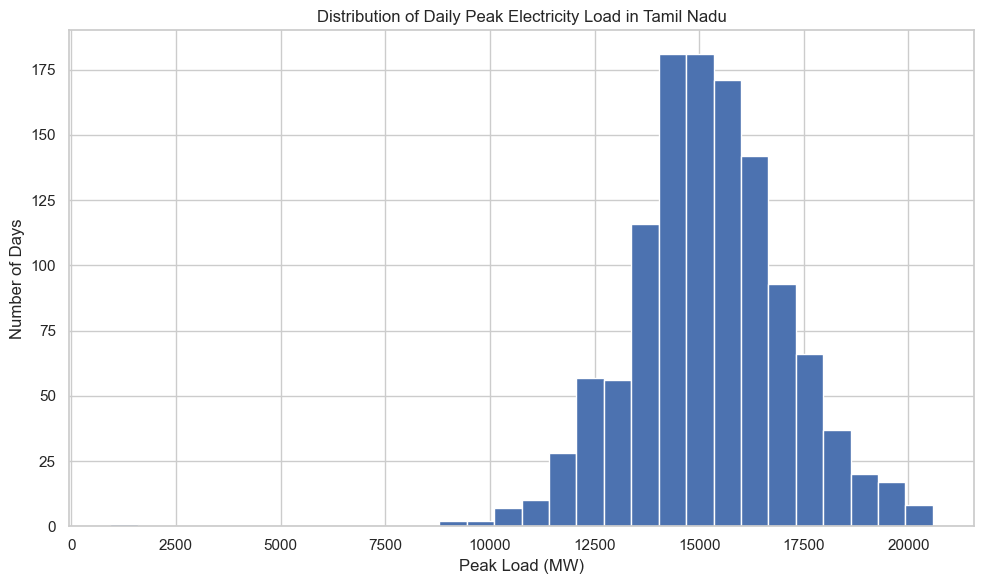

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(merged_df["Peak_Load_MW"].dropna(), bins=30)
plt.title("Distribution of Daily Peak Electricity Load in Tamil Nadu")
plt.xlabel("Peak Load (MW)")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()


# 5.1 TREND ANALYSIS

This analysis examines how electricity peak load and energy supplied change over the study period from January 2021 to April 2024. It helps identify long-term trends, seasonal patterns, high-demand periods, and unusual changes in electricity demand.

## 5.1.1 Daily Peak Load Trend


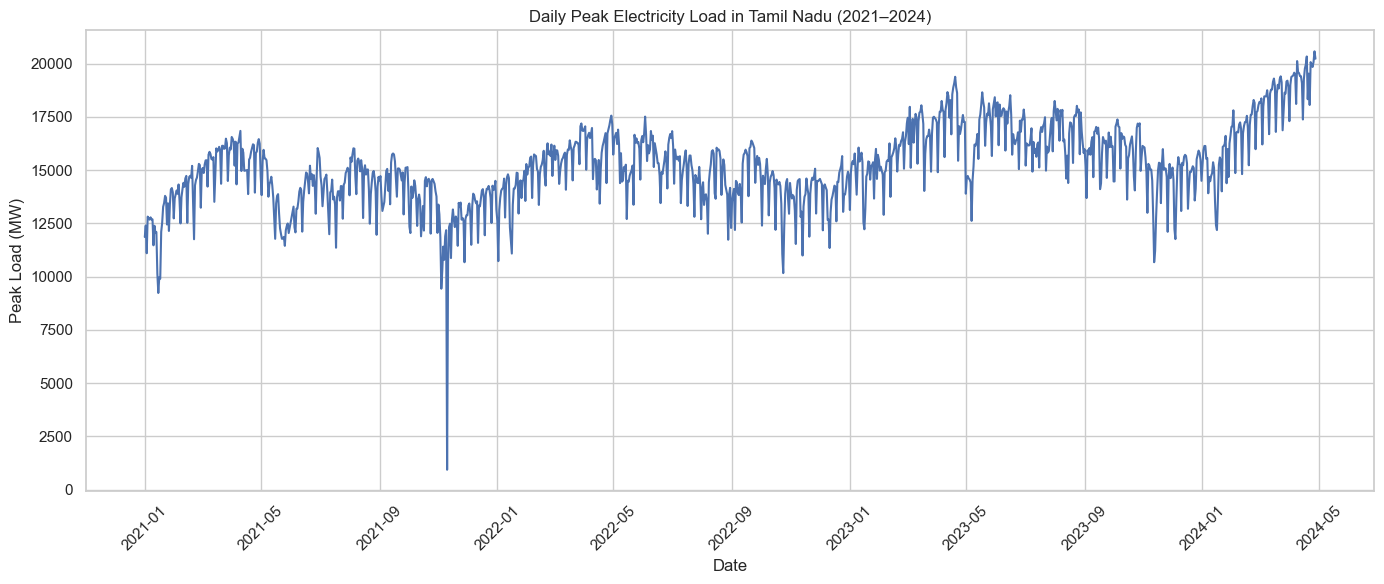

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(merged_df["Date"], merged_df["Peak_Load_MW"], linewidth=1.5)
plt.title("Daily Peak Electricity Load in Tamil Nadu (2021–2024)")
plt.xlabel("Date")
plt.ylabel("Peak Load (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5.1.2 Daily Energy Supplied Trend


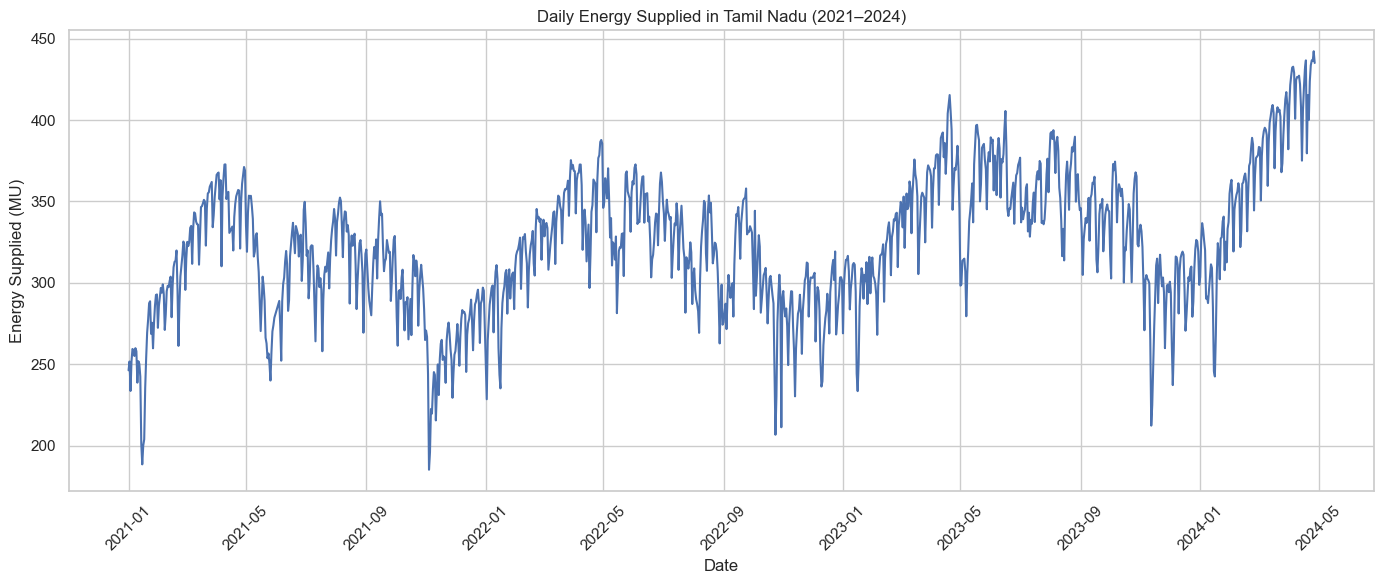

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(merged_df["Date"], merged_df["Energy_Supplied_MU"], linewidth=1.5)
plt.title("Daily Energy Supplied in Tamil Nadu (2021–2024)")
plt.xlabel("Date")
plt.ylabel("Energy Supplied (MU)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5.1.3 Daily Unmet Demand Trend


**Interpretation note:** The Tamil Nadu unmet-demand series is flat for the selected study period. This is retained as a data-quality/coverage finding rather than artificially modifying the values to create visual variation.


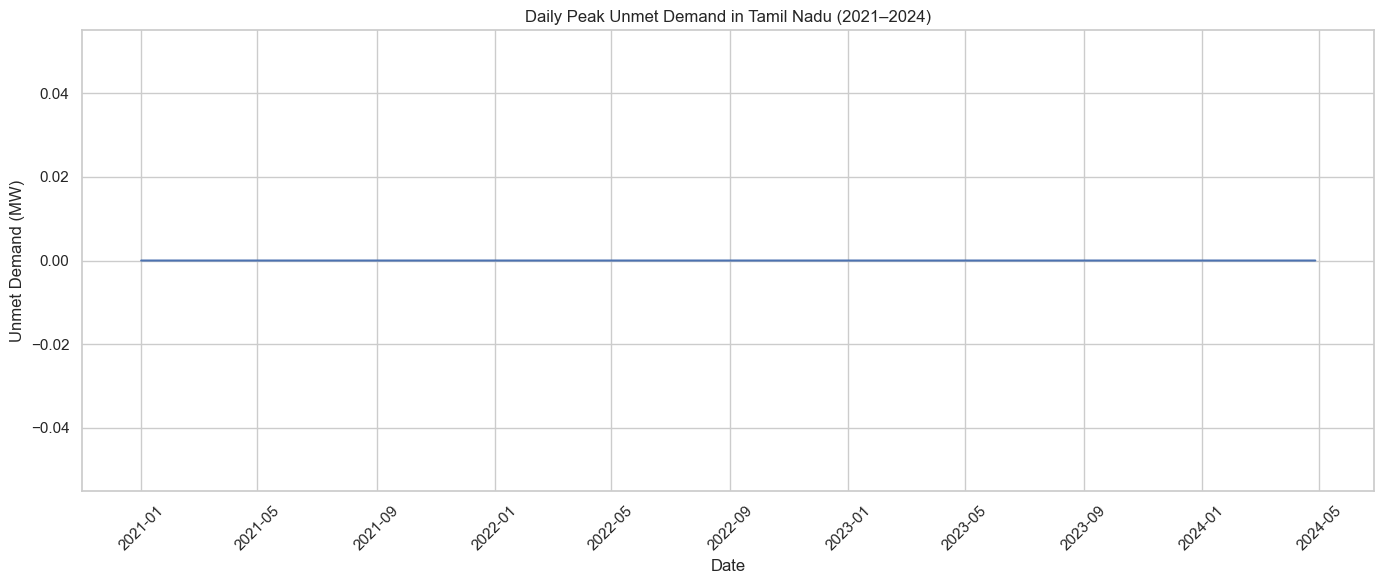

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(merged_df["Date"], merged_df["Unmet_Demand_MW"], linewidth=1.5)
plt.title("Daily Peak Unmet Demand in Tamil Nadu (2021–2024)")
plt.xlabel("Date")
plt.ylabel("Unmet Demand (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5.2 Comparison Analysis

This analysis compares electricity demand across different years and identifies the highest-demand days.
It helps highlight yearly variations and periods with exceptionally high electricity load

## 5.2.1 Year-wise Peak Load Comparison


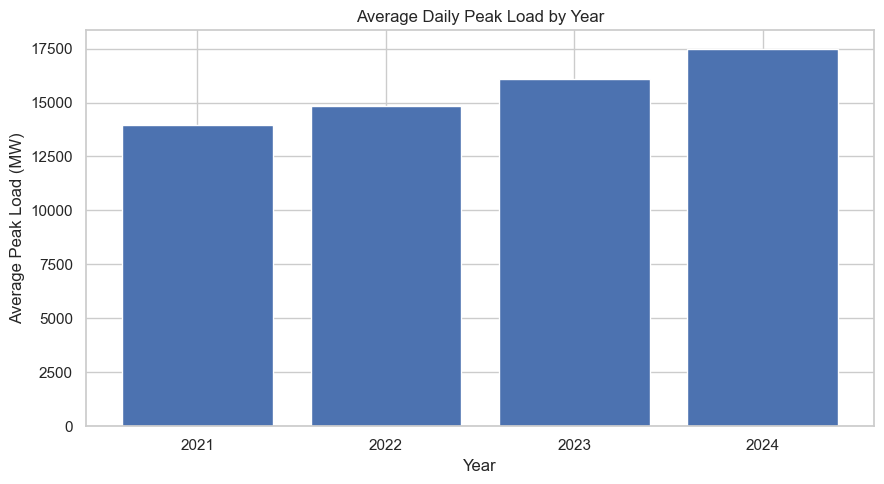

,Year,Peak_Load_MW
0,2021,13955.53
1,2022,14848.16
2,2023,16087.79
3,2024,17470.71


In [24]:
year_peak = merged_df.groupby("Year")["Peak_Load_MW"].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.bar(year_peak["Year"].astype(str), year_peak["Peak_Load_MW"])
plt.title("Average Daily Peak Load by Year")
plt.xlabel("Year")
plt.ylabel("Average Peak Load (MW)")
plt.tight_layout()
plt.show()

display(year_peak.round(2))


## 5.2.1 Year-wise Energy Supplied Comparison

Year-wise average energy supplied is compared to identify changes in electricity supply across the study period. Average values are used so that the incomplete 2024 period is not directly compared with complete-year totals.


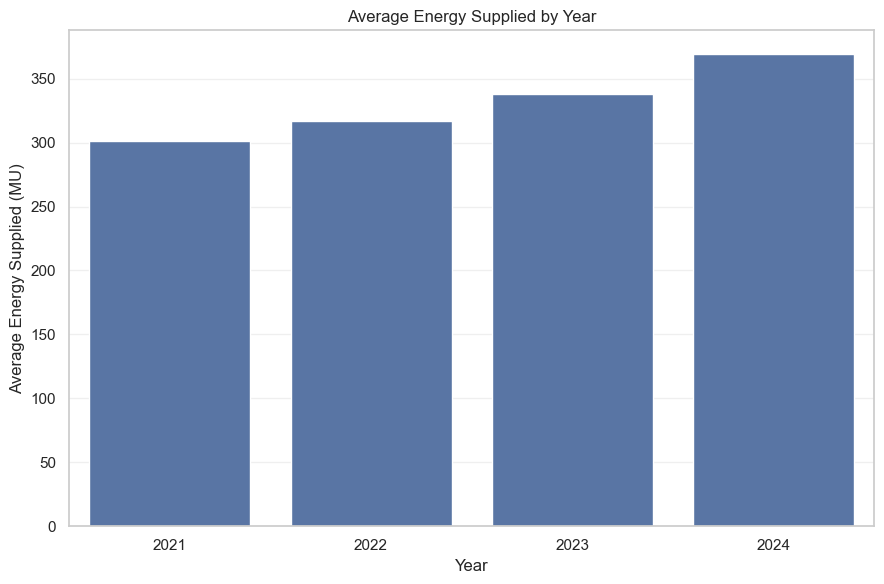

In [25]:
yearly_energy = (
    merged_df.groupby("Year", observed=True)["Energy_Supplied_MU"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=yearly_energy, x="Year", y="Energy_Supplied_MU", errorbar=None)
plt.title("Average Energy Supplied by Year")
plt.xlabel("Year")
plt.ylabel("Average Energy Supplied (MU)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 5.3 Time-based Analysis

This analysis examines electricity demand according to months and year-month combinations.
It helps identify recurring monthly and seasonal patterns in peak electricity load.

## 5.3.1 Monthly Peak Load Analysis

Monthly averages help identify recurring seasonal demand patterns.


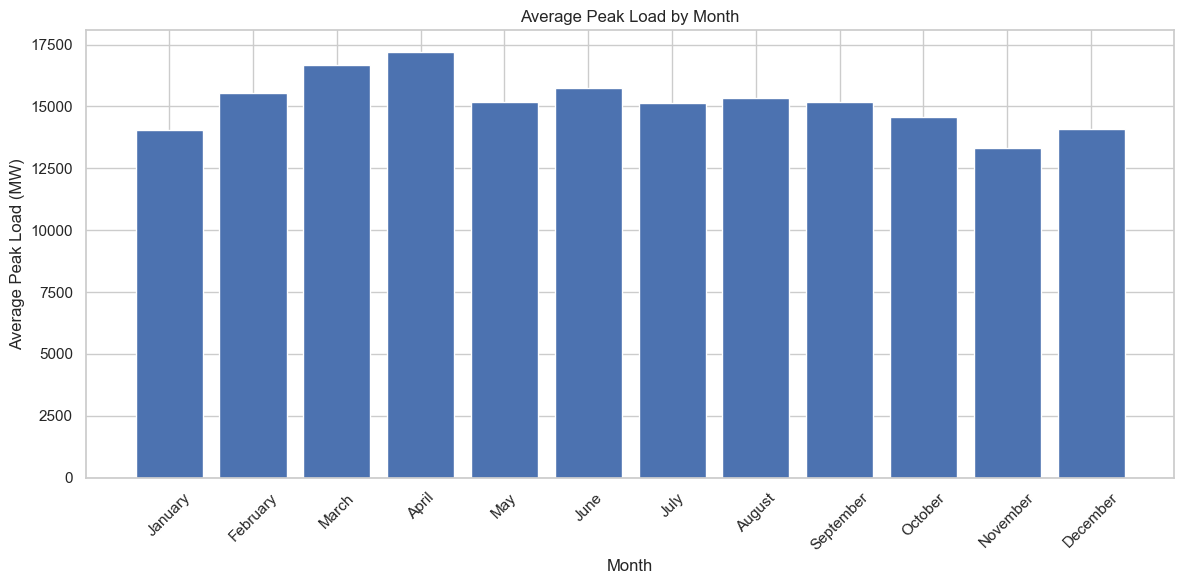

,Month_Name,Peak_Load_MW
0,January,14059.45
1,February,15535.83
2,March,16671.36
3,April,17211.97
4,May,15164.98
5,June,15743.14
6,July,15138.70
7,August,15343.26
8,September,15190.68
9,October,14565.49


In [26]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_peak = (
    merged_df.groupby("Month_Name", observed=True)["Peak_Load_MW"]
    .mean()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.bar(monthly_peak["Month_Name"], monthly_peak["Peak_Load_MW"])
plt.title("Average Peak Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Peak Load (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly_peak.round(2))


## 5.3.2 Monthly Energy Supplied Analysis

Monthly average energy supplied is examined in chronological order from January to December. This helps identify recurring seasonal supply patterns without treating the partial 2024 period as a complete year.


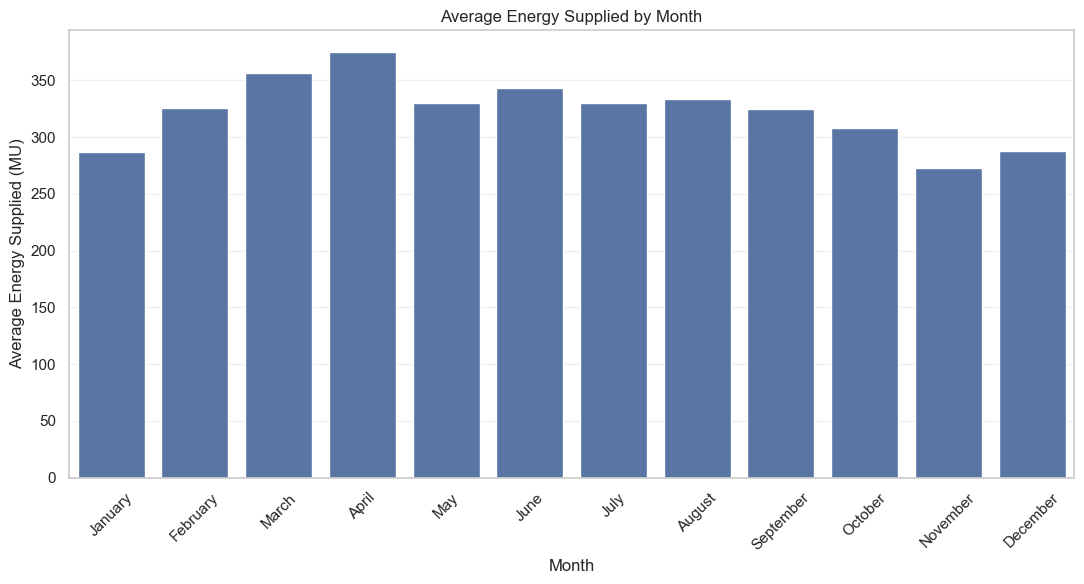

In [27]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_energy = (
    merged_df.groupby("Month_Name", observed=True)["Energy_Supplied_MU"]
    .mean()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(11, 6))
sns.barplot(data=monthly_energy, x="Month_Name", y="Energy_Supplied_MU", errorbar=None)
plt.title("Average Energy Supplied by Month")
plt.xlabel("Month")
plt.ylabel("Average Energy Supplied (MU)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5.3.3 Year-Month Heatmap of Peak Load


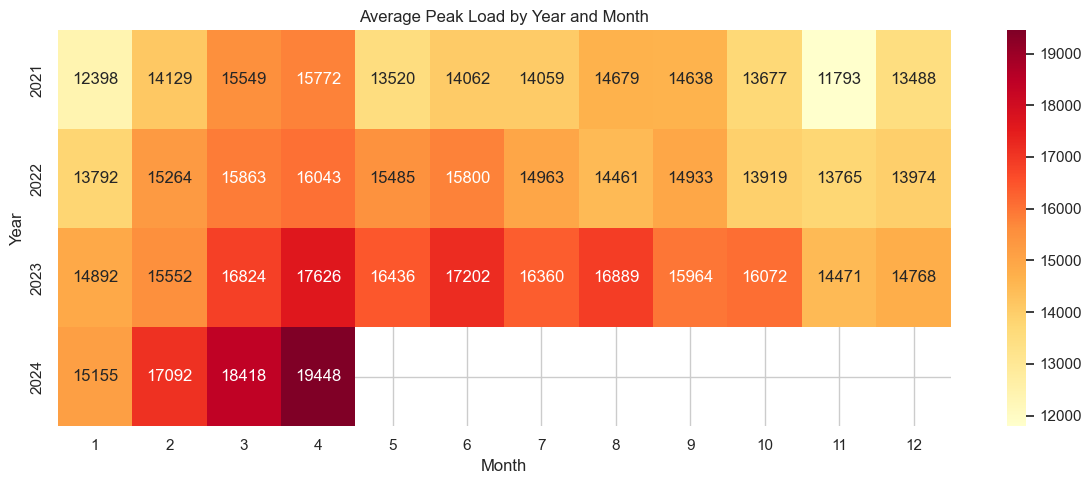

In [28]:
year_month_peak = merged_df.pivot_table(
    index="Year",
    columns="Month",
    values="Peak_Load_MW",
    aggfunc="mean"
)

plt.figure(figsize=(12, 5))
sns.heatmap(year_month_peak, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Average Peak Load by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()


# 5.4 Category-wise Analysis


This analysis compares electricity demand across different categories such as years and days of the week. It helps identify differences in electricity demand between weekdays, weekends, and different years

## 5.4.1 Day-of-Week Analysis


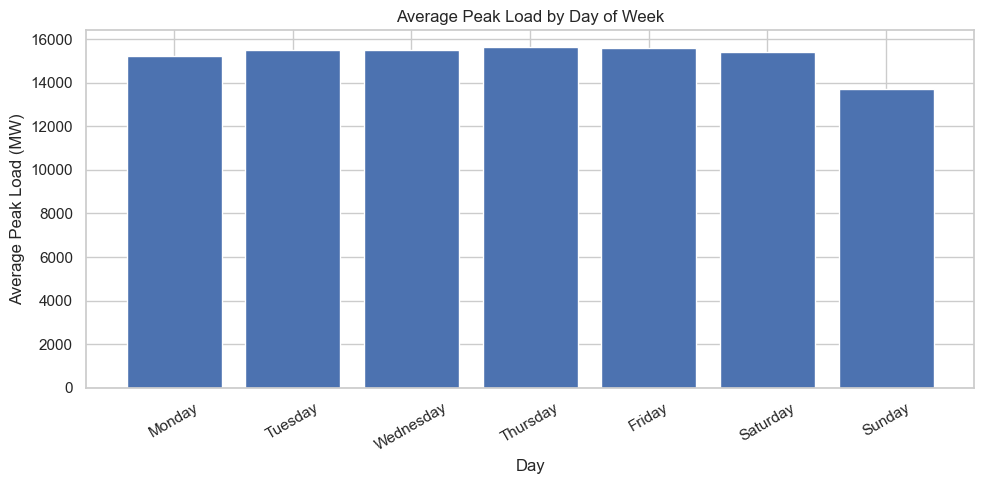

,Day_of_Week,Peak_Load_MW
0,Monday,15240.64
1,Tuesday,15478.29
2,Wednesday,15503.89
3,Thursday,15617.22
4,Friday,15607.59
5,Saturday,15402.22
6,Sunday,13719.99


In [29]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_peak = (
    merged_df.groupby("Day_of_Week", observed=True)["Peak_Load_MW"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(day_peak["Day_of_Week"], day_peak["Peak_Load_MW"])
plt.title("Average Peak Load by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Peak Load (MW)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(day_peak.round(2))


# 5.5 Relationship Analysis

Weather variables are compared with electricity indicators to explore whether demand conditions vary with temperature, thermal comfort and other atmospheric variables.


## 5.5.1 Temperature vs Peak Load


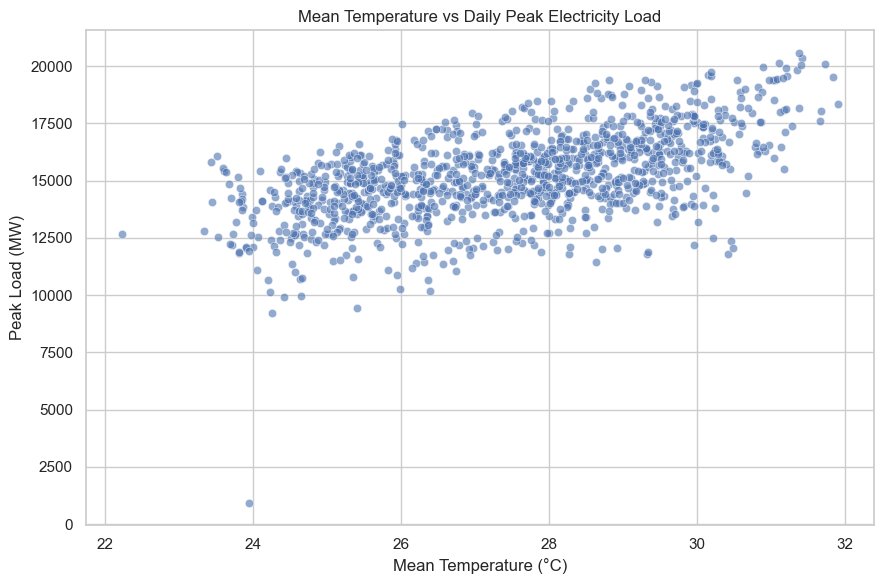

In [30]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=merged_df, x="Temperature_C_mean", y="Peak_Load_MW", alpha=0.6)
plt.title("Mean Temperature vs Daily Peak Electricity Load")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Peak Load (MW)")
plt.tight_layout()
plt.show()


## 5.5.2 Maximum Temperature vs Peak Load


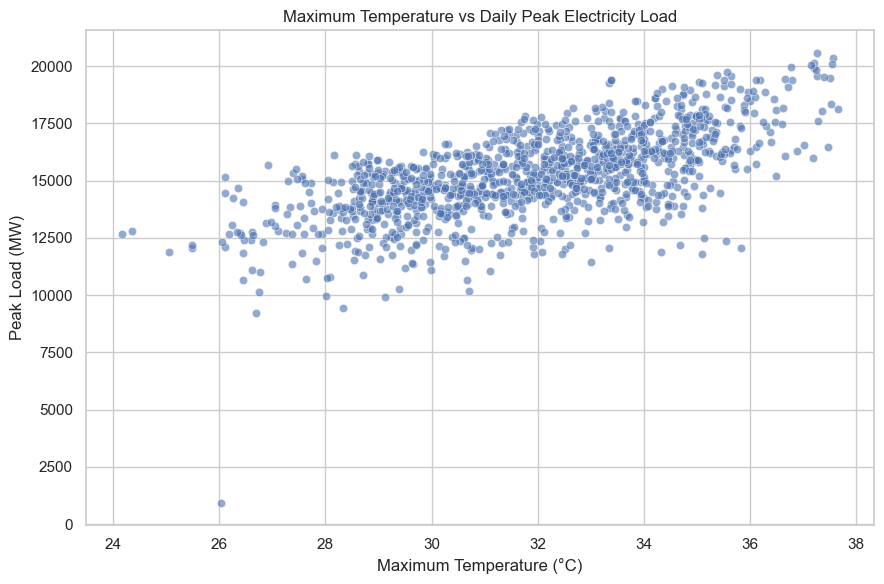

In [31]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=merged_df, x="Temperature_C_max", y="Peak_Load_MW", alpha=0.6)
plt.title("Maximum Temperature vs Daily Peak Electricity Load")
plt.xlabel("Maximum Temperature (°C)")
plt.ylabel("Peak Load (MW)")
plt.tight_layout()
plt.show()


## 5.5.3 Solar Radiation vs Peak Load


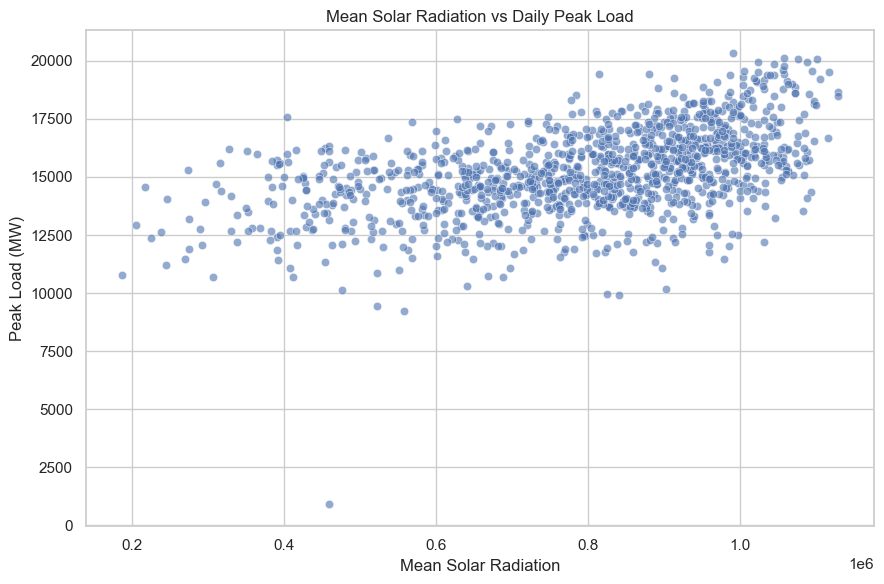

In [32]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=merged_df,
    x="surface_solar_radiation_downwards_mean",
    y="Peak_Load_MW",
    alpha=0.6
)
plt.title("Mean Solar Radiation vs Daily Peak Load")
plt.xlabel("Mean Solar Radiation")
plt.ylabel("Peak Load (MW)")
plt.tight_layout()
plt.show()


## 5.5.4 UTCI vs Peak Load


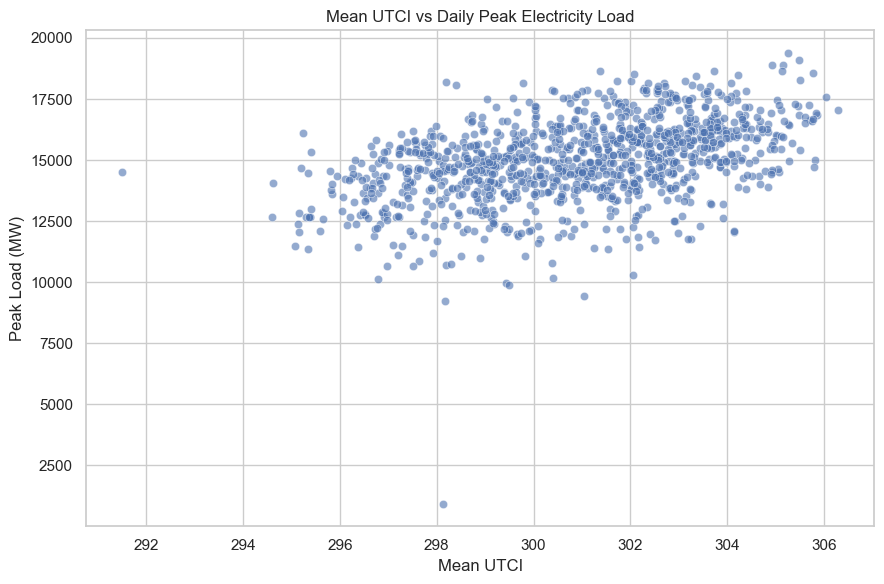

In [33]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=merged_df, x="utci_mean", y="Peak_Load_MW", alpha=0.6)
plt.title("Mean UTCI vs Daily Peak Electricity Load")
plt.xlabel("Mean UTCI")
plt.ylabel("Peak Load (MW)")
plt.tight_layout()
plt.show()


## 5.5.5 Peak Load vs Energy Supplied


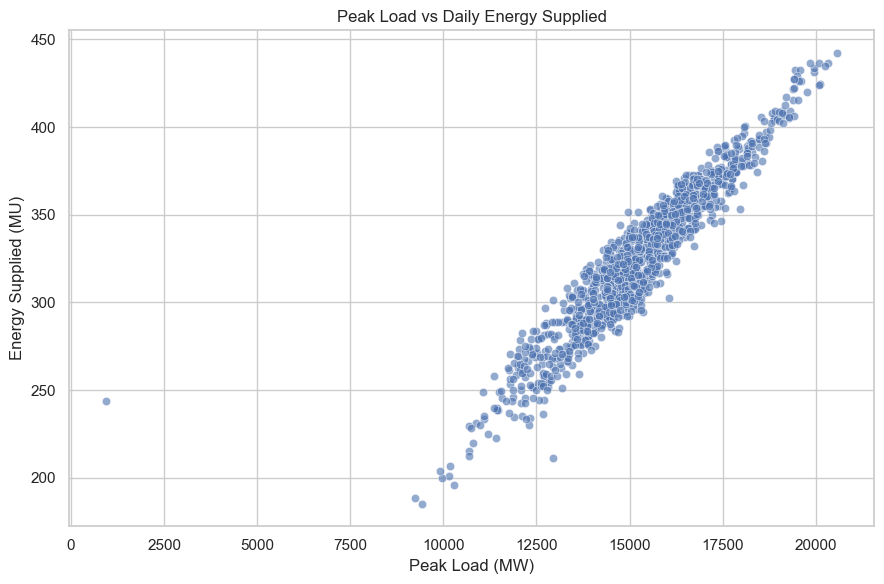

In [35]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=merged_df, x="Peak_Load_MW", y="Energy_Supplied_MU", alpha=0.6)
plt.title("Peak Load vs Daily Energy Supplied")
plt.xlabel("Peak Load (MW)")
plt.ylabel("Energy Supplied (MU)")
plt.tight_layout()
plt.show()


# 5.6 Correlation Analysis

Correlation analysis is used to examine linear relationships among the main electricity and weather variables. The unmet-demand field is intentionally excluded from the correlation matrix because the Tamil Nadu records in the selected period show no variation in this variable. A constant variable cannot provide a meaningful correlation measure.


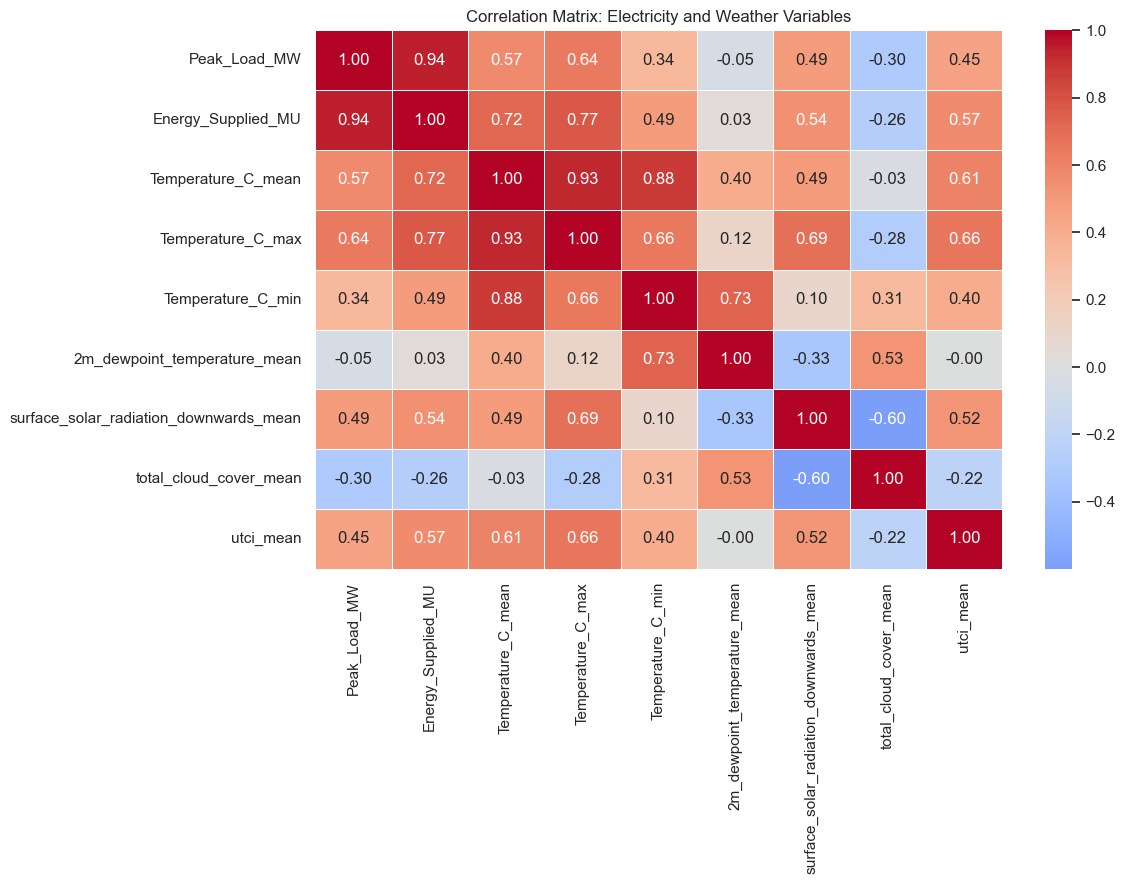

In [34]:
corr_columns = [
    "Peak_Load_MW",
    "Energy_Supplied_MU",
    "Temperature_C_mean",
    "Temperature_C_max",
    "Temperature_C_min",
    "2m_dewpoint_temperature_mean",
    "surface_solar_radiation_downwards_mean",
    "total_cloud_cover_mean",
    "utci_mean"
]

correlation_matrix = merged_df[corr_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix: Electricity and Weather Variables")
plt.tight_layout()
plt.show()


# 5.7 Distribution analysis

The highest-demand days are extracted to identify periods that deserve closer attention.


In [36]:
top_peak_days = (
    merged_df[["Date", "Peak_Load_MW", "Unmet_Demand_MW", "Energy_Supplied_MU", "Temperature_C_mean"]]
    .sort_values("Peak_Load_MW", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top 15 peak-load days")
display(top_peak_days.round(2))


Top 15 peak-load days


,Date,Peak_Load_MW,Unmet_Demand_MW,Energy_Supplied_MU,Temperature_C_mean
0,2024-04-26,20583.0,0.0,442.3,31.38
1,2024-04-18,20341.0,0.0,436.7,31.43
2,2024-04-27,20237.0,0.0,435.1,NaN
3,2024-04-08,20125.0,0.0,424.6,31.12
4,2024-04-22,20077.0,0.0,423.8,31.73
5,2024-04-25,20076.0,0.0,436.3,31.41
6,2024-04-17,19964.0,0.0,431.3,30.90
7,2024-04-23,19944.0,0.0,433.6,31.20
8,2024-04-24,19849.0,0.0,436.7,31.35
9,2024-04-16,19764.0,0.0,419.9,30.19


In [37]:
top_unmet_days = (
    merged_df[["Date", "Unmet_Demand_MW", "Peak_Load_MW", "Energy_Supplied_MU", "Temperature_C_mean"]]
    .sort_values("Unmet_Demand_MW", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top 15 unmet-demand days")
display(top_unmet_days.round(2))


Top 15 unmet-demand days


,Date,Unmet_Demand_MW,Peak_Load_MW,Energy_Supplied_MU,Temperature_C_mean
0,2021-01-01,0.0,11864.0,246.3,23.81
1,2023-04-01,0.0,17249.0,365.5,29.46
2,2023-03-29,0.0,17512.0,372.2,29.23
3,2023-03-28,0.0,17467.0,367.9,29.43
4,2023-03-27,0.0,16713.0,349.3,29.56
5,2023-03-26,0.0,14931.0,324.9,28.89
6,2023-03-25,0.0,16552.0,352.4,28.99
7,2023-03-24,0.0,16907.0,353.8,28.63
8,2023-03-23,0.0,16599.0,355.4,28.68
9,2023-03-22,0.0,16602.0,353.0,29.11


## 5.7.1 Top Peak Load Days Visualization


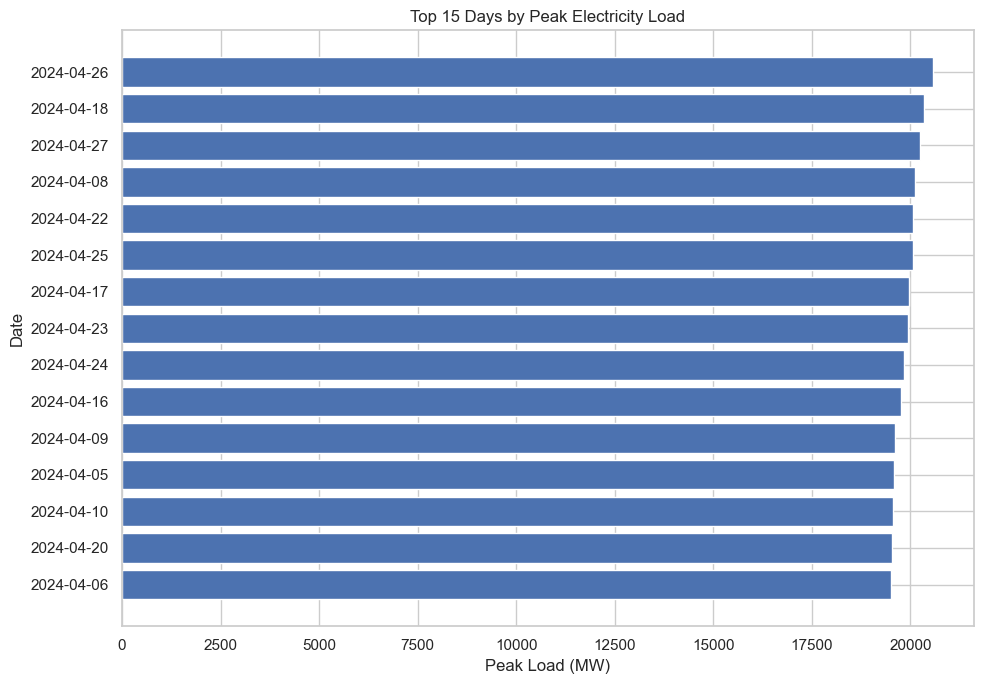

In [38]:
plot_df = top_peak_days.sort_values("Peak_Load_MW", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["Date"].astype(str), plot_df["Peak_Load_MW"])
plt.title("Top 15 Days by Peak Electricity Load")
plt.xlabel("Peak Load (MW)")
plt.ylabel("Date")
plt.tight_layout()
plt.show()


## 5.7.2 Monthly and Yearly Summary Tables

Summary tables provide compact numerical results that can later be used in the project report.


In [39]:
monthly_summary = merged_df.groupby(["Year", "Month", "Month_Name"], observed=True).agg(
    Avg_Peak_Load_MW=("Peak_Load_MW", "mean"),
    Max_Peak_Load_MW=("Peak_Load_MW", "max"),
    Avg_Unmet_Demand_MW=("Unmet_Demand_MW", "mean"),
    Max_Unmet_Demand_MW=("Unmet_Demand_MW", "max"),
    Avg_Energy_Supplied_MU=("Energy_Supplied_MU", "mean"),
    Avg_Temperature_C=("Temperature_C_mean", "mean")
).reset_index()

display(monthly_summary.round(2).head(30))


,Year,Month,Month_Name,Avg_Peak_Load_MW,Max_Peak_Load_MW,Avg_Unmet_Demand_MW,Max_Unmet_Demand_MW,Avg_Energy_Supplied_MU,Avg_Temperature_C
0,2021,1,January,12398.35,14163.0,0.0,0.0,254.42,24.72
1,2021,2,February,14129.48,15298.0,0.0,0.0,298.88,25.42
2,2021,3,March,15549.30,16481.0,0.0,0.0,340.02,28.08
3,2021,4,April,15771.52,16846.0,0.0,0.0,352.98,29.90
4,2021,5,May,13520.47,15957.0,0.0,0.0,300.26,29.48
5,2021,6,June,14061.96,16040.0,0.0,0.0,313.28,29.14
6,2021,7,July,14058.60,15579.0,0.0,0.0,310.36,28.39
7,2021,8,August,14679.48,16029.0,0.0,0.0,322.84,28.22
8,2021,9,September,14637.96,15786.0,0.0,0.0,316.16,28.10
9,2021,10,October,13677.23,14675.0,0.0,0.0,292.54,26.86


In [40]:
yearly_summary = merged_df.groupby("Year").agg(
    Avg_Peak_Load_MW=("Peak_Load_MW", "mean"),
    Max_Peak_Load_MW=("Peak_Load_MW", "max"),
    Avg_Unmet_Demand_MW=("Unmet_Demand_MW", "mean"),
    Max_Unmet_Demand_MW=("Unmet_Demand_MW", "max"),
    Avg_Energy_Supplied_MU=("Energy_Supplied_MU", "mean"),
    Total_Energy_Supplied_MU=("Energy_Supplied_MU", "sum"),
    Avg_Temperature_C=("Temperature_C_mean", "mean")
).reset_index()

display(yearly_summary.round(2))


,Year,Avg_Peak_Load_MW,Max_Peak_Load_MW,Avg_Unmet_Demand_MW,Max_Unmet_Demand_MW,Avg_Energy_Supplied_MU,Total_Energy_Supplied_MU,Avg_Temperature_C
0,2021,13955.53,16846.0,0.0,0.0,301.29,106053.1,27.34
1,2022,14848.16,17563.0,0.0,0.0,317.01,114440.1,27.22
2,2023,16087.79,19387.0,0.0,0.0,337.81,122963.0,27.67
3,2024,17470.71,20583.0,0.0,0.0,369.30,43577.9,27.90


## 5.7.3 Boxplots for Main Electricity Variables

Peak load and energy supplied use different units (MW and MU), so they are displayed in separate boxplots rather than on a common numerical axis. This makes the distribution and potential outliers easier to interpret correctly.


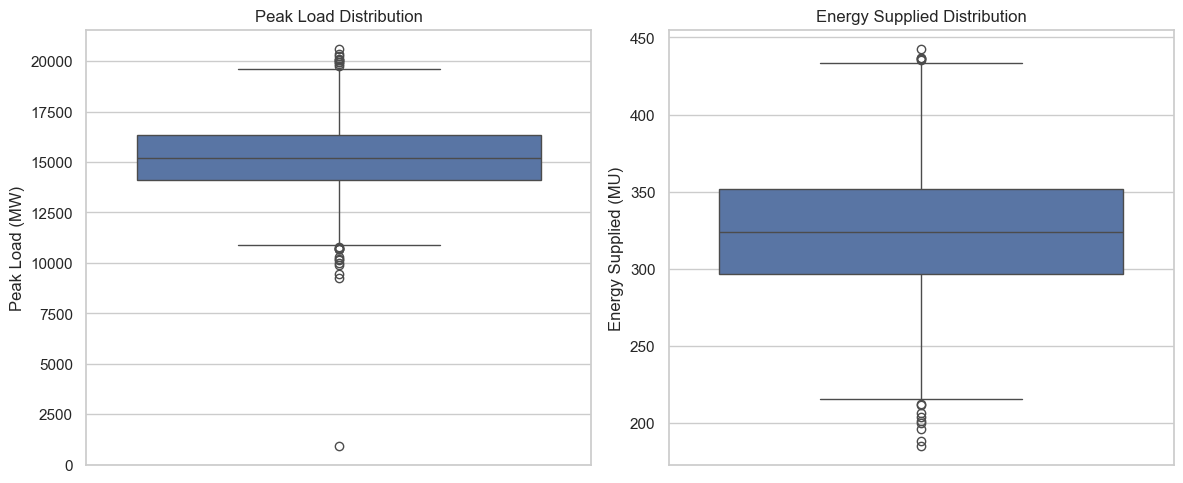

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=merged_df["Peak_Load_MW"], ax=axes[0])
axes[0].set_title("Peak Load Distribution")
axes[0].set_ylabel("Peak Load (MW)")

sns.boxplot(y=merged_df["Energy_Supplied_MU"], ax=axes[1])
axes[1].set_title("Energy Supplied Distribution")
axes[1].set_ylabel("Energy Supplied (MU)")

plt.tight_layout()
plt.show()


# 5.8 Outlier Analysis Using IQR

The Interquartile Range (IQR) method is used to identify unusually high or low observations. An observation is treated as an IQR outlier when it falls below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.


In [41]:
def iqr_summary(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return {
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": len(outliers)
    }

outlier_variables = ["Peak_Load_MW", "Unmet_Demand_MW", "Energy_Supplied_MU", "Temperature_C_mean"]
outlier_variables = [c for c in outlier_variables if c in merged_df.columns]

outlier_summary = pd.DataFrame([iqr_summary(merged_df, c) for c in outlier_variables])
display(outlier_summary.round(2))


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Peak_Load_MW,14111.50,16312.00,2200.50,10810.75,19612.75,23
1,Unmet_Demand_MW,0.00,0.00,0.00,0.00,0.00,0
2,Energy_Supplied_MU,296.70,351.90,55.20,213.90,434.70,14
3,Temperature_C_mean,25.87,28.96,3.09,21.23,33.60,0


## 5.8.2 Temperature and Peak Load Seasonal Comparison


This comparison is used to identify whether temperature and peak-load patterns move similarly across months. It shows seasonal association only and should not be interpreted as proof that temperature causes the observed electricity demand.


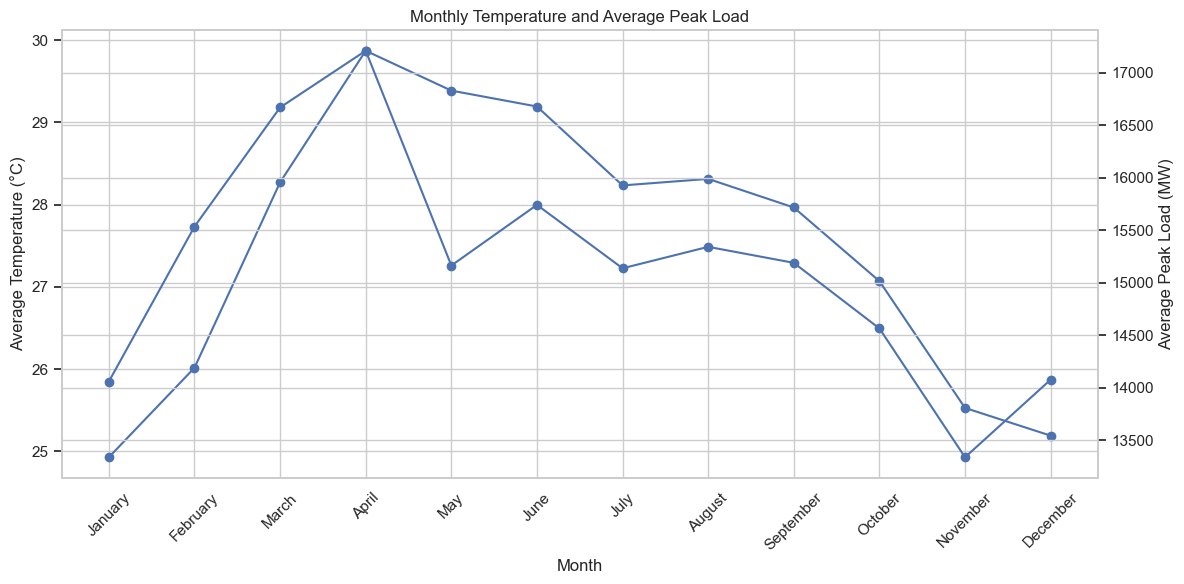

,Month_Name,Avg_Temperature_C,Avg_Peak_Load_MW
0,January,24.93,14059.45
1,February,26.02,15535.83
2,March,28.27,16671.36
3,April,29.87,17211.97
4,May,29.39,15164.98
5,June,29.19,15743.14
6,July,28.23,15138.70
7,August,28.31,15343.26
8,September,27.97,15190.68
9,October,27.07,14565.49


In [43]:
monthly_weather_peak = merged_df.groupby("Month_Name", observed=True).agg(
    Avg_Temperature_C=("Temperature_C_mean", "mean"),
    Avg_Peak_Load_MW=("Peak_Load_MW", "mean")
).reindex(month_order).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly_weather_peak["Month_Name"], monthly_weather_peak["Avg_Temperature_C"], marker="o", label="Temperature (°C)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Temperature (°C)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_weather_peak["Month_Name"], monthly_weather_peak["Avg_Peak_Load_MW"], marker="o", label="Peak Load (MW)")
ax2.set_ylabel("Average Peak Load (MW)")

plt.title("Monthly Temperature and Average Peak Load")
plt.tight_layout()
plt.show()

display(monthly_weather_peak.round(2))


# 6. Key Analytical Tables

The following tables summarize the most useful findings from the exploratory analysis. The focus is placed on peak load, energy supplied and weather relationships because the unmet-demand field has no variation in the selected Tamil Nadu records.


In [44]:
print("Top 10 months by average Peak Load:")
print(
    monthly_summary
    .sort_values("Avg_Peak_Load_MW", ascending=False)
    [["Year", "Month_Name", "Avg_Peak_Load_MW", "Max_Peak_Load_MW"]]
    .head(10)
)

print("\nTop 10 months by average Energy Supplied:")
print(
    monthly_summary
    .sort_values("Avg_Energy_Supplied_MU", ascending=False)
    [["Year", "Month_Name", "Avg_Energy_Supplied_MU"]]
    .head(10)
)

peak_correlations = (
    correlation_matrix["Peak_Load_MW"]
    .drop("Peak_Load_MW")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("\nStrongest correlations with Peak Load:")
print(peak_correlations)

print("\nUnmet-demand observation:")
print(merged_df["Unmet_Demand_MW"].describe())


Top 10 months by average Peak Load:
    Year Month_Name  Avg_Peak_Load_MW  Max_Peak_Load_MW
39  2024      April      19448.000000           20583.0
38  2024      March      18417.967742           19409.0
27  2023      April      17626.233333           19387.0
29  2023       June      17201.633333           18522.0
37  2024   February      17092.172414           18299.0
31  2023     August      16889.290323           18252.0
26  2023      March      16824.200000           18048.0
28  2023        May      16436.193548           18658.0
30  2023       July      16359.580645           17774.0
33  2023    October      16071.903226           17386.0

Top 10 months by average Energy Supplied:
    Year Month_Name  Avg_Energy_Supplied_MU
39  2024      April              420.692593
38  2024      March              392.603226
27  2023      April              376.170000
29  2023       June              368.820000
31  2023     August              366.003226
37  2024   February              359.2689

# 20. Final Data and Output Files

This notebook intentionally produces exactly **five CSV output files**:

### Four cleaned source datasets
- `clean_peak_met_MW.csv`
- `clean_peak_unmet_MW.csv`
- `clean_daily_energy_met_MU.csv`
- `clean_tamil_nadu_weather.csv`

### One merged dataset
- `Tamil_Nadu_TANGEDCO_Merged_2021_2024.csv`

No separate Tamil Nadu-only CSV files and no separate analysis-ready CSV are created.


# 22. Conclusion

This notebook provides a complete, reproducible exploratory-analysis workflow for **Exploratory Analysis of TANGEDCO Electricity Demand**. The data pipeline is deliberately kept to exactly five CSV outputs: four independently cleaned source datasets and one merged Tamil Nadu analytical dataset. Tamil Nadu electricity columns are selected in memory after cleaning, without creating extra intermediate CSV files. The merged dataset is saved immediately after the merge and before feature engineering or EDA.

All final interpretations should be written from the actual tables, statistics and plots produced when the notebook is executed.
